In [1]:
!pip install pytextrank
!pip install spacy

In [2]:
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
import spacy
import pytextrank
import re


# load a spaCy model, depending on language, scale, etc.
nlp = spacy.load("en_core_web_sm")

# Add the textrank algorithm to the spacy pipeline
nlp.add_pipe("textrank")

# We want to cleanup the text a bit.
text = 'Hurricane Gilbert swept toward the Dominican Republic Sunday, and the Civil Defense alerted its heavily populated south coast to prepare for high winds, heavy rains and high seas. The National Hurricane Center in Miami reported its position at 2 a.m. Sunday at latitude 16.1 north, longitude 67.5 west, about 140 miles south of Ponce, Puerto Rico, and 200 miles southeast of Santo Domingo. The National Weather Service in San Juan, Puerto Rico, said Gilbert was moving westward at 15 mph with a "broad area of cloudiness and heavy weather" rotating around the center of the storm. Strong winds associated with Gilbert brought coastal flooding, strong southeast winds and up to 12 feet to Puerto Rico’s south coast.'
text = text.replace("\n", "").replace("\r", "")
text = re.sub(' +', ' ', text)
# The doc now contains the summary. That is it!
doc = nlp(text)

resulting_sentences = 5
# Print out the results
for sentence in doc._.textrank.summary(limit_sentences=resulting_sentences):
    print(sentence)

Hurricane Gilbert swept toward the Dominican Republic Sunday, and the Civil Defense alerted its heavily populated south coast to prepare for high winds, heavy rains and high seas.
Strong winds associated with Gilbert brought coastal flooding, strong southeast winds and up to 12 feet to Puerto Rico’s south coast.
The National Weather Service in San Juan, Puerto Rico, said Gilbert was moving westward at 15 mph with a "broad area of cloudiness and heavy weather" rotating around the center of the storm.
The National Hurricane Center in Miami reported its position at 2 a.m. Sunday at latitude 16.1 north, longitude 67.5 west, about 140 miles south of Ponce, Puerto Rico, and 200 miles southeast of Santo Domingo.


In [8]:
!pip install networkx
!pip install matplotlib
!pip install numpy

In [17]:
!pip install langchain -q
!pip install youtube-transcript-api -q
!pip install pytube -q
!pip install langchain-community -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.3/622.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.3 MB/s eta 0:00:00


In [32]:
!pip install git+https://github.com/pytube/pytube


  Cloning https://github.com/pytube/pytube to /tmp/pip-req-build-yq1xbunc
  Running command git clone --filter=blob:none --quiet https://github.com/pytube/pytube /tmp/pip-req-build-yq1xbunc
  Resolved https://github.com/pytube/pytube to commit a32fff39058a6f7e5e59ecd06a7467b71197ce35
  Preparing metadata (setup.py) ... done


In [39]:
!pip install --upgrade langchain langchain-community


In [40]:
from langchain_community.document_loaders import YoutubeLoader
from langchain.chains.summarize import load_summarize_chain
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [63]:
import re

def extract_video_id(url):
    # Expresión regular para encontrar el ID de un video de YouTube
    pattern = r'(?:youtube\.com\/(?:[^\/\n\s]+\/\S+\/|(?:v|e(?:mbed)?)\/|.*[?&]v=)|youtu\.be\/|.*[?&]v=)([a-zA-Z0-9_-]{11})'

    match = re.search(pattern, url)

    if match:
        return match.group(1)
    else:
        return None

# Ejemplos de uso
url_1 = 'https://www.youtube.com/watch?v=lf6FnoJDqgg'


ul = extract_video_id(url_1)
print(f"ID del video 1: {extract_video_id(url_1)}")
print(ul)



ID del video 1: lf6FnoJDqgg
lf6FnoJDqgg


In [64]:
from youtube_transcript_api import YouTubeTranscriptApi

# ID del video de YouTube
vid_id = ul  # Este es el ID del video

try:
    # Descargar la transcripción
    transcript = YouTubeTranscriptApi.get_transcript(vid_id, languages=['es'])

    # Mostrar la transcripción en pantalla
    for entry in transcript:
        print(f"{entry['start']}: {entry['text']}")
except Exception as e:
    print(f"Ocurrió un error: {e}")



3.54: [Música]
5.55: [Aplausos]
8.2: cómo les va muy pero muy buenas tardes
10.48: Bienvenidos a un nuevo capítulo de todos
12.36: somos técnicos un capítulo especial a
15.12: ver vamos a hablar de muchas cosas el
17.16: terremoto de la propiedad de la
18.64: Universidad de chile las novedades de
20.8: Colo Colo vamos a tener una entrevista
23.199: también pero es un capítulo especial
25.199: Porque otra vez Este programa que no se
28.96: cansa está nominado al copihue de
33.719: oro El Tri campeón va por el tetra no
38.48: Solo lo hemos ganado una dos tres
42.16: veces ahora queremos ir por el cuarto
45.28: copi de oro el que tiene en sus manos
48.28: Marcelo Díaz es uno el que tiene en sus
50.039: manos Cartagena es otro el que tiene en
52.399: sus manos Vero Bianchi es otro el qué
56.92: año tiene por ejemplo este es 2021 fue
59.519: en el mes de mayo ahora no sé cuándo se
62.399: ahora en enero creo en pantalla para Ah
65.4: que este fue en pandemia Este es el del
66.84: 2023 203 e

In [54]:
!pip install youtube_transcript_api spacy networkx matplotlib pytextrank
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 17.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.



Chunks más importantes según TextRank:

Chunk 1:
buen partido para Francia iba a terminar cayendo sorpresivamente 1 a0 frente a Tunes Y tampoco fue un gran partido de colomo aní en los siguientes partidos de octavos y cuartos de final directamente no entró estuvo sentado en el banco de suplentes Sin embargo en semifinales se le iba a volver a presentar una oportunidad importante des champs con el partido 1 a0 frente a Marruecos le daba la chance de ingresar como extremo derecho en los últimos 10 minutos del partido y coloman iba a pagar con creces gran ingreso del delantero francés que iba a terminar marcando.

Chunk 2:
del fútbol francés retornó al nantes y recién a partir del año 2020 tuvo algo de regularidad y empezó a jugar mucho más seguido en el nantes en el equipo en el cual se había formado en dos temporadas jugó 87 encuentros y marcó 23 goles viendo que estaba mejorando y que era un jugador joven varios equipos se interesaron en él y con como terminaba su contrato decidió no 

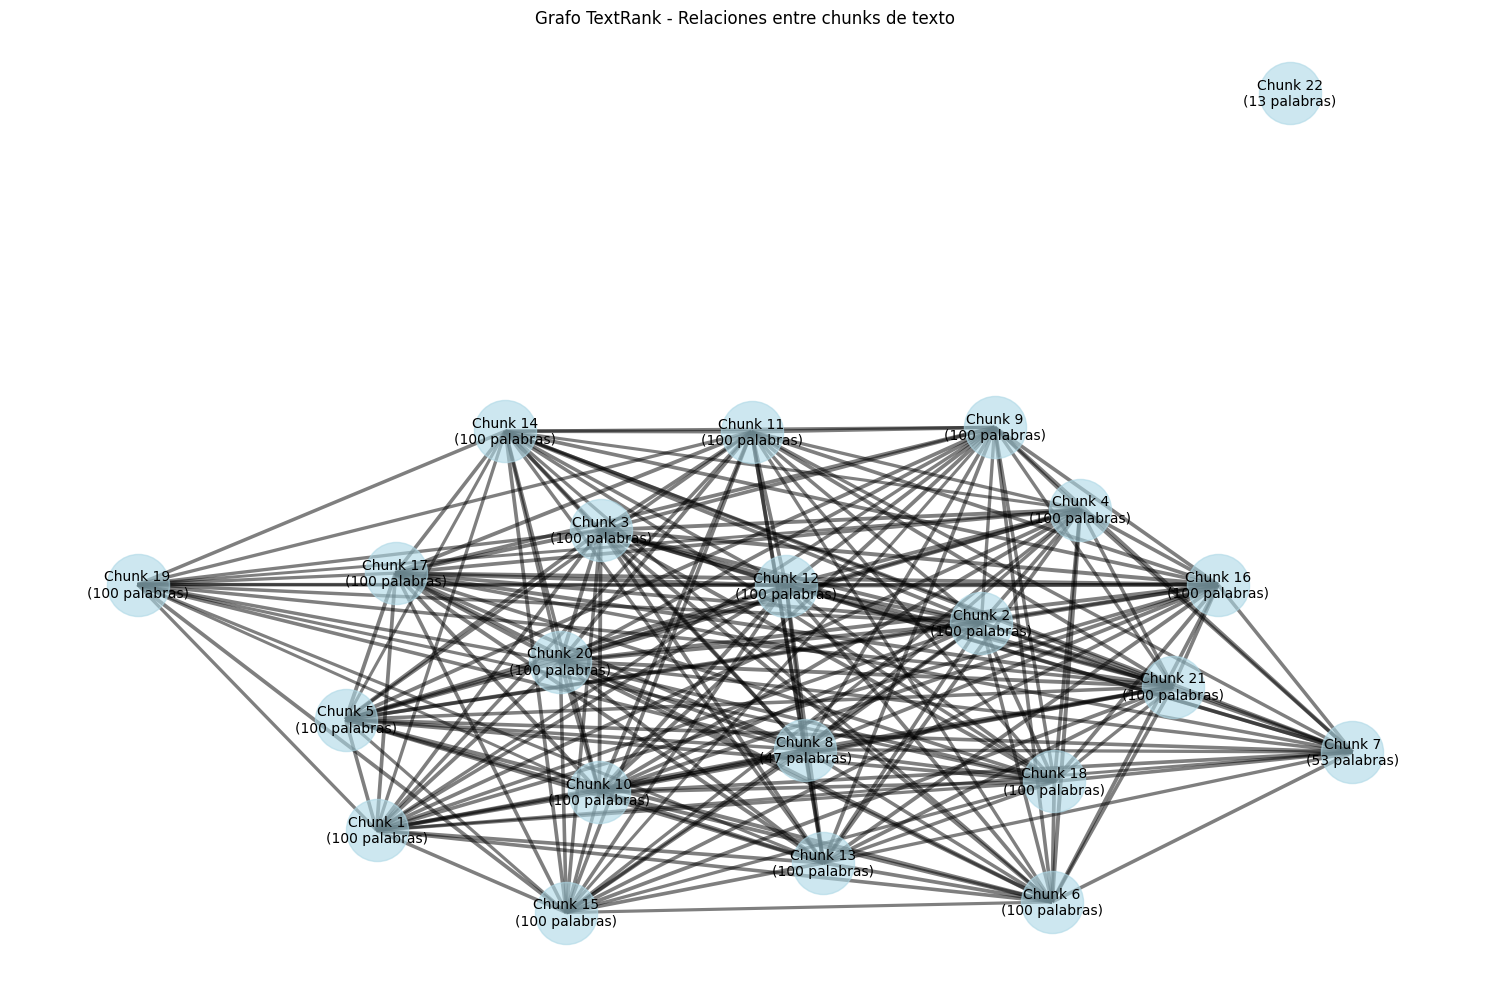


Información detallada de cada chunk:

Chunk 1 (100 palabras):
[Música] chananan [Música] chanan Hola gente cómo andan un saludo grande para todos Yo soy s Les traigo un nuevo video al Canal en el día de hoy vamos a estar hablando acerca de un protagonista que tuvo el mundial de ar pero un protagonista No por algo positivo sino por algo negativo y que lamentablemente después de ese suceso en los últimos dos años su carrera poco a poco ha ido en caída libre al punto tal en que hoy en día su equipo no lo tiene en cuenta Vamos a repasar un poco Quién era ese jugador este.

Chunk 2 (100 palabras):
momento culmina en el mundial de Qatar y lo que le ha ocurrido en los últimos dos años Así que espero que les guste la idea del video que dejen su me gusta y se suscriban al Canal activando la campanita que me sigan en las redes sociales y sin dar mucha vuelta comen amos con la idea del video la selección francesa es sin duda hoy en día uno de los seleccionados que mayor cantidad de talentos cons

In [55]:
from youtube_transcript_api import YouTubeTranscriptApi
import spacy
import pytextrank
import re
import networkx as nx
import matplotlib.pyplot as plt

def chunk_text(text, words_per_chunk=100):
    """
    Divide el texto en chunks de aproximadamente n palabras,
    intentando no cortar en medio de una palabra.
    """
    words = text.split()
    chunks = []
    current_chunk = []
    current_count = 0

    for word in words:
        current_chunk.append(word)
        current_count += 1

        # Si llegamos al límite de palabras o encontramos un punto
        if current_count >= words_per_chunk or word.endswith('.'):
            chunks.append(' '.join(current_chunk))
            current_chunk = []
            current_count = 0

    # Añadir el último chunk si quedaron palabras
    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks

# ID del video de YouTube
vid_id = 'fPXkMqn781c'

try:
    # Descargar la transcripción
    transcript = YouTubeTranscriptApi.get_transcript(vid_id, languages=['es'])

    # Unir las transcripciones en un solo texto
    text = " ".join([entry['text'] for entry in transcript])

    # Limpiar el texto
    text = text.replace("\n", "").replace("\r", "")
    text = re.sub(' +', ' ', text)

    # Dividir el texto en chunks
    chunks = chunk_text(text, words_per_chunk=100)

    # Crear un nuevo texto con los chunks separados por puntos
    processed_text = ". ".join(chunks)

    # Procesar el texto con spaCy
    nlp = spacy.load("es_core_news_md")
    nlp.add_pipe("textrank")

    # Procesar el texto
    doc = nlp(processed_text)

    # Imprimir los chunks más importantes según TextRank
    print("\nChunks más importantes según TextRank:")
    for i, sent in enumerate(doc._.textrank.summary(limit_sentences=5)):
        print(f"\nChunk {i+1}:")
        print(sent)

    # Crear el grafo
    G = nx.Graph()

    # Añadir nodos (chunks)
    sentences = list(doc.sents)
    for i, sent in enumerate(sentences):
        G.add_node(i, text=sent.text)

    # Añadir aristas basadas en similitud
    for i in range(len(sentences)):
        for j in range(i + 1, len(sentences)):
            similarity = sentences[i].similarity(sentences[j])
            if similarity > 0.7:  # Bajamos el umbral de similitud
                G.add_edge(i, j, weight=similarity)

    # Configurar la visualización
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos,
                          node_color='lightblue',
                          node_size=2000,
                          alpha=0.6)

    # Dibujar aristas con grosor basado en el peso
    edges = G.edges(data=True)
    weights = [d['weight']*3 for (u, v, d) in edges]
    nx.draw_networkx_edges(G, pos,
                          width=weights,
                          alpha=0.5)

    # Añadir etiquetas a los nodos
    labels = {i: f"Chunk {i+1}\n({len(sent.text.split())} palabras)" for i, sent in enumerate(sentences)}
    nx.draw_networkx_labels(G, pos, labels, font_size=10)

    # Ajustar el diseño
    plt.title("Grafo TextRank - Relaciones entre chunks de texto", pad=20)
    plt.axis('off')
    plt.tight_layout()

    # Mostrar el grafo
    plt.show()

    # Imprimir información detallada de cada chunk
    print("\nInformación detallada de cada chunk:")
    for i, chunk in enumerate(sentences):
        print(f"\nChunk {i+1} ({len(chunk.text.split())} palabras):")
        print(chunk.text)

except Exception as e:
    print(f"Ocurrió un error: {e}")